In [1]:
# mamba activate spatialdata_env
import tifffile
import os
from spatialdata.models import Image2DModel
import spatialdata_io
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
from spatialdata.models import ShapesModel
import anndata
import scanpy as sc
from spatialdata import SpatialData
from spatialdata import polygon_query
from spatialdata import bounding_box_query
# from napari_spatialdata import Interactive
from spatialdata.models import TableModel
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from spatialdata import SpatialData
from napari.utils.colormaps import Colormap
from napari_spatialdata import Interactive
import spatialdata as sd
from scipy import ndimage as ndi
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from spatialdata.transformations import (
    BaseTransformation,
    Identity,
    Sequence,
    align_elements_using_landmarks,
    get_transformation,
    set_transformation,
    Affine
)

In [ ]:
path_orig = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/'
sdata = sd.read_zarr(path_orig + 'output-XETG00202__0059709_Left__SCAF04480_Left_R1__20250403__144627.zarr')

In [ ]:
# Interactive(sdata)

In [ ]:
path_zarr = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/nb_orig_label_v1.zarr'
sdata.write(path_zarr,overwrite=True)

In [ ]:
path_zarr = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/nb_orig_label_v1.zarr'
sdata = sd.read_zarr(path_zarr)

In [ ]:
# Interactive(sdata)

In [ ]:
plygoneList = [l for l in sdata.shapes.keys() if l not in ('cell_boundaries')]

In [ ]:
from tqdm import tqdm
sdata['table'].obs['sample_id'] = 'remove'
df = sdata['table'].obs
for pg in tqdm(plygoneList):
    polygon = sdata.shapes[pg].geometry.iloc[0]
    ind = polygon_query(sdata['cell_boundaries'],polygon,target_coordinate_system="global").index.tolist()
    df.loc[df['cell_id'].isin(ind),'sample_id'] = pg
    del ind

In [ ]:
andata = sdata['table']

In [ ]:
andata = andata[~andata.obs['sample_id'].isin(['remove'])]

In [ ]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
andata.write_h5ad(os.path.join(pathout, "andata_nb_orig.h5ad"))

In [ ]:
path_zarr = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/nb_orig_label_v1.zarr'
sdata = sd.read_zarr(path_zarr)

In [ ]:
Interactive(sdata)

# Metadata

In [2]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
adata = sc.read_h5ad(os.path.join(pathout, "andata_nb_orig.h5ad"))

In [6]:
table = pd.read_csv('./data_in/05082026_Sample_punch_id.csv')

In [7]:
table.columns

Index(['Sample#', 'Sample ID', 'Cap', 'Ear tag', 'Condition', 'Type',
       'Observation ', 'punch_id'],
      dtype='object')

In [8]:
table = table[['Sample#', 'Ear tag', 'Condition', 'Type','punch_id']]


In [9]:
table_exploded = table.copy()

table_exploded["punch_id"] = (
    table_exploded["punch_id"]
    .astype(str)
    .str.split(",")
)

table_exploded = table_exploded.explode("punch_id")

table_exploded["punch_id"] = table_exploded["punch_id"].str.strip().astype(int)

table_exploded

,Sample#,Ear tag,Condition,Type,punch_id
0,1,181.0,IL-15.CAR,Primary,41
0,1,181.0,IL-15.CAR,Primary,46
1,2,181.0,IL-15.CAR,Metastasis,36
1,2,181.0,IL-15.CAR,Metastasis,31
2,3,191.0,IL-15.CAR,Primary,48
3,4,191.0,IL-15.CAR,Metastasis,26
3,4,191.0,IL-15.CAR,Metastasis,21
4,5,195.0,IL-15.CAR,Primary,11
4,5,195.0,IL-15.CAR,Primary,16
5,6,195.0,IL-15.CAR,Metastasis,1


In [10]:
table_exploded['Condition'].replace({'IL-15.IL-21.CAR': 'both', 'IL-21.CAR': 'IL21', 'IL-15.CAR': 'IL15'}, inplace=True)

/tmp/ipykernel_1714451/2802444843.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  table_exploded['Condition'].replace({'IL-15.IL-21.CAR': 'both', 'IL-21.CAR': 'IL21', 'IL-15.CAR': 'IL15'}, inplace=True)


In [21]:
table_exploded.rename(columns={'Ear tag': 'mouse_id'}, inplace=True)

In [19]:
table_exploded['punch_id'] = table_exploded['punch_id'].astype(str)

In [24]:
columns_add = table_exploded.columns

In [13]:
adata.obs['punch_id'] = adata.obs['sample_id'].astype(str)


In [25]:
df = adata.obs.merge(table_exploded, on='punch_id')[columns_add]
for col in columns_add:
    adata.obs[col] = df[col].values

In [34]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
adata.write_h5ad(os.path.join(pathout, "andata_nb_orig.h5ad"))

In [39]:
len(adata.obs['Sample#'].unique())

28

In [40]:
path_zarr = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/nb_orig_label_v1.zarr'
sdata = sd.read_zarr(path_zarr)

/tmp/ipykernel_1714451/1456852835.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(path_zarr)
no parent found for <ome_zarr.reader.Label object at 0x1553efbb6ed0>: None
no parent found for <ome_zarr.reader.Label object at 0x1553efca86d0>: None


In [52]:
df_2sdata

,Sample#,mouse_id,Condition,Type,punch_id
0,5,195.0,IL15,Primary,11
1,4,191.0,IL15,Metastasis,21
2,4,191.0,IL15,Metastasis,21
3,4,191.0,IL15,Metastasis,21
4,4,191.0,IL15,Metastasis,21
...,...,...,...,...,...
688483,19,185.0,CAR,Metastasis,24
688484,19,185.0,CAR,Metastasis,24
688485,19,185.0,CAR,Metastasis,24
688486,19,185.0,CAR,Metastasis,24


In [54]:
sdata['table'] = sdata['table'][sdata['table'].obs['cell_id'].isin(adata.obs['cell_id'])]

In [55]:
sdata['table'].shape

(688488, 5006)

In [56]:
df_2sdata = sdata['table'].obs.merge(adata.obs, on='cell_id')[columns_add]
for col in columns_add:
    sdata['table'].obs[col] = df_2sdata[col].values

/tmp/ipykernel_1714451/2500406545.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata['table'].obs[col] = df_2sdata[col].values


In [70]:
sdata['table'].obs.rename(columns={'Sample#': 'sample_lab'}, inplace=True)

In [75]:
obs = sdata["table"].obs

# Define punch_id order numerically, not alphabetically
punch_order = sorted(
    obs["punch_id"].astype(str).unique(),
    key=lambda x: int(x)
)

# Reassign punch_id as an ordered categorical
obs["punch_id"] = pd.Categorical(
    obs["punch_id"].astype(str),
    categories=punch_order,
    ordered=True
)

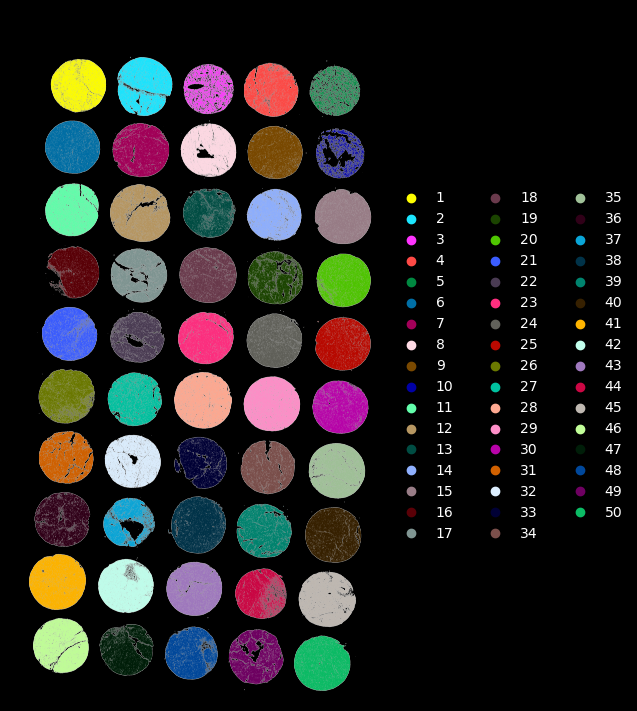

In [73]:
plt.style.use("dark_background")
ax = sdata.pl.render_labels(element="cell_labels", color="punch_id",
    fill_alpha=0.9, 
    method="matplotlib",table_name='table').pl.show(coordinate_systems='global',title=f" ",figsize=(7, 7),dpi = 100,na_in_legend=False,legend_loc = 'right margin',return_ax=True)
ax.set_axis_off()
plt.show()

In [84]:
sdata['table'].obs['mouse_id'] = sdata['table'].obs['mouse_id'].astype(str).astype('category')

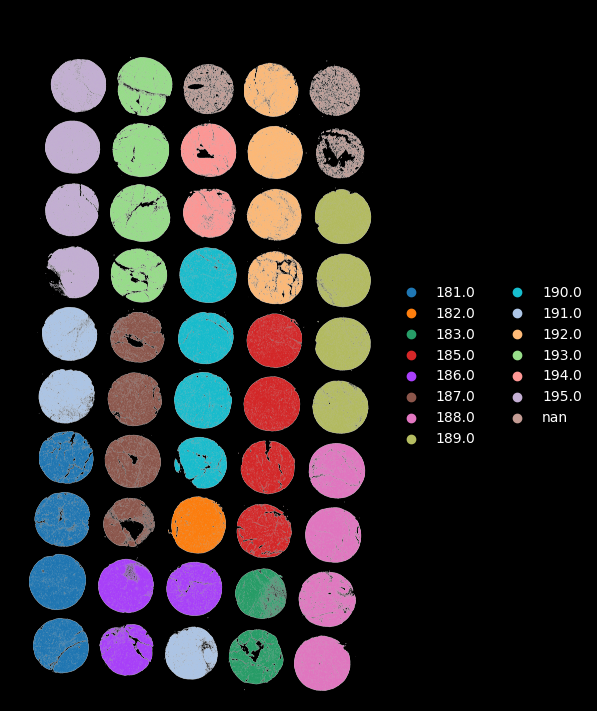

In [85]:
plt.style.use("dark_background")
ax = sdata.pl.render_labels(element="cell_labels", color="mouse_id",
    fill_alpha=0.9, 
    method="matplotlib",table_name='table').pl.show(coordinate_systems='global',title=f" ",figsize=(7, 7),dpi = 100,na_in_legend=False,legend_loc = 'right margin',return_ax=True)
ax.set_axis_off()
plt.show()

In [87]:
sdata['table'].obs['Condition']
obs = sdata['table'].obs
# Reassign punch_id as an ordered categorical
obs["Condition"] = pd.Categorical(
    obs["Condition"].astype(str),
    categories=['Mock','CAR','IL15','IL21','both'],
    ordered=True
)

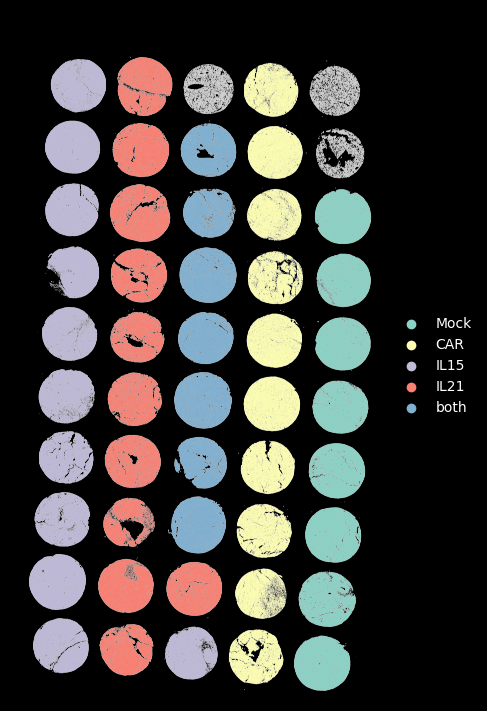

In [88]:
plt.style.use("dark_background")
ax = sdata.pl.render_labels(element="cell_labels", color="Condition",
    fill_alpha=0.9, 
    method="matplotlib",table_name='table').pl.show(coordinate_systems='global',title=f" ",figsize=(7, 7),dpi = 100,na_in_legend=False,legend_loc = 'right margin',return_ax=True)
ax.set_axis_off()
plt.show()

In [90]:
obs = sdata['table'].obs
# Reassign punch_id as an ordered categorical
obs["Type"] = pd.Categorical(
    obs["Type"].astype(str),
    categories=['Primary','Metastasis'],
    ordered=True
)

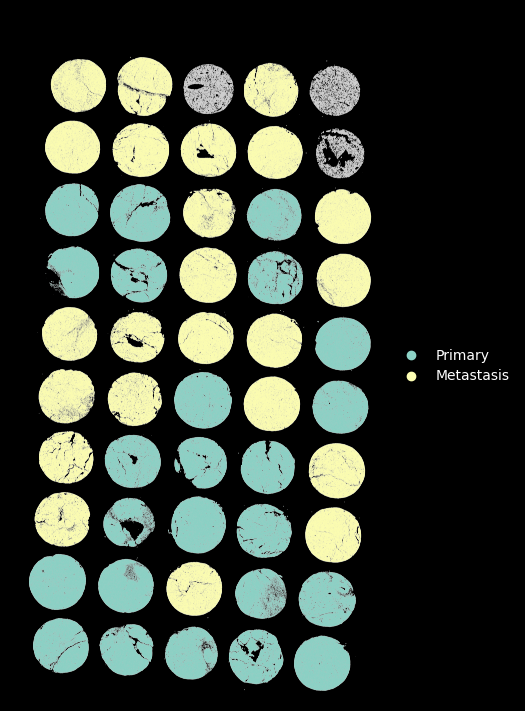

In [92]:
plt.style.use("dark_background")
ax = sdata.pl.render_labels(element="cell_labels", color="Type",
    fill_alpha=0.9, 
    method="matplotlib",table_name='table').pl.show(coordinate_systems='global',title=f" ",figsize=(7, 7),dpi = 100,na_in_legend=False,legend_loc = 'right margin',return_ax=True)
ax.set_axis_off()
plt.show()

In [95]:
sdata['table'].obs['sample_lab'] = sdata['table'].obs['sample_lab'].astype(str).astype('category')

In [97]:
sdata['table'].obs['sample_lab'] = sdata['table'].obs['sample_lab'].astype(str).astype('category')
obs = sdata["table"].obs

# Define sample_lab order numerically, not alphabetically
sample_lab_order = sorted(
    obs["sample_lab"].astype(str).unique(),
    key=lambda x: int(x)
)

# Reassign sample_lab as an ordered categorical
obs["sample_lab"] = pd.Categorical(
    obs["sample_lab"].astype(str),
    categories=sample_lab_order,
    ordered=True
)

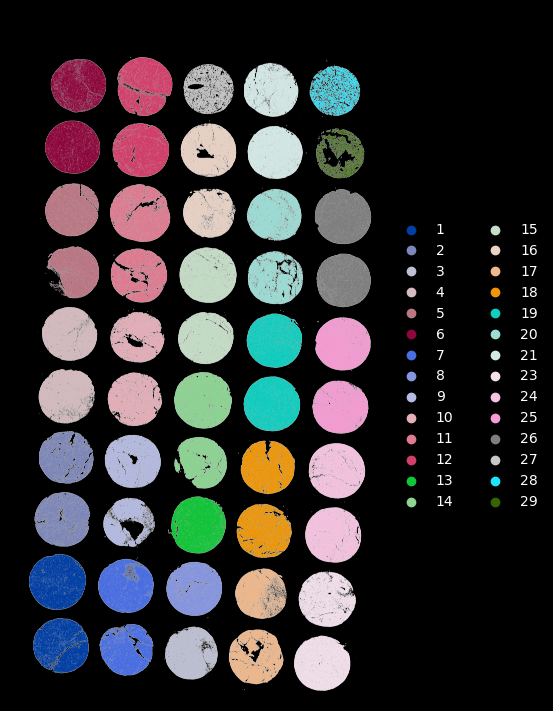

In [98]:
plt.style.use("dark_background")
ax = sdata.pl.render_labels(element="cell_labels", color="sample_lab",
    fill_alpha=0.9, 
    method="matplotlib",table_name='table').pl.show(coordinate_systems='global',title=f" ",figsize=(7, 7),dpi = 100,na_in_legend=False,legend_loc = 'right margin',return_ax=True)
ax.set_axis_off()
plt.show()

In [99]:
path_zarr = '/data/HiTIF/data/spatialomics/neuroblastoma/data/SCAF4480/PrimaryAnalysisOutput/SCAF4480_PA_xenium/nb_orig_label_v1_metadata.zarr'
sdata.write(path_zarr,overwrite=True)

/vf/users/kanferg/conda_v1/envs/spatiocore_spatial_env/lib/python3.11/site-packages/ome_zarr/writer.py:319: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  da_delayed = da.to_zarr(


In [100]:
andata = sdata['table']

In [101]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
andata.write_h5ad(os.path.join(pathout, "andata_nb_orig_metadata.h5ad"))